In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cdist

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score

from scipy.stats import spearmanr

# Code for Metric Score Calculations

In [2]:
def full_cw_sil_score(X, labels):

    X = np.asarray(X)
    labels = np.asarray(labels)

    n = len(X)
    unique_labels = np.unique(labels)

    #pairwise distance matrix
    D = cdist(X, X)

    # computation of centroids
    centroids = {
        l: X[labels == l].mean(axis=0)
        for l in unique_labels
    }

    # distance to centroid
    dist_to_centroid = np.zeros(n)
    for i in range(n):
        d = np.linalg.norm(X[i] - centroids[labels[i]])
        dist_to_centroid[i] = d + 1e-8   # to avoid zero

    silhouette_scores = np.zeros(n)

    for i in range(n):

        # a(i) 
        same_cluster = (labels == labels[i])
        same_cluster[i] = False  # to exclude self

        if not np.any(same_cluster):
            silhouette_scores[i] = 0
            continue

        intra_dist = D[i, same_cluster]
        intra_weights = 1.0 / dist_to_centroid[same_cluster]

        a = np.sum(intra_dist * intra_weights) / np.sum(intra_weights)

        # b(i)
        b = np.inf

        for l in unique_labels:
            if l == labels[i]:
                continue

            mask = (labels == l)
            inter_dist = D[i, mask]
            inter_weights = 1.0 / dist_to_centroid[mask]

            b_l = np.sum(inter_dist * inter_weights) / np.sum(inter_weights)
            b = min(b, b_l)

        # silhouette score for i
        silhouette_scores[i] = (b - a) / max(a, b)

    return silhouette_scores.mean()

In [3]:
def cw_sil_score(X, labels):

    X = np.asarray(X)
    labels = np.asarray(labels)

    n = len(X)
    unique_labels = np.unique(labels)

    # pairwise distance matrix
    D = cdist(X, X)

    # centroids
    centroids = {
        l: X[labels == l].mean(axis=0)
        for l in unique_labels
    }

    # distance to centroid
    dist_to_centroid = np.zeros(n)
    for i in range(n):
        d = np.linalg.norm(X[i] - centroids[labels[i]])
        dist_to_centroid[i] = d + 1e-8   # avoid zero

    silhouette_scores = np.zeros(n)

    for i in range(n):

        # a(i) 
        same_cluster = (labels == labels[i])
        same_cluster[i] = False  # exclude self

        if not np.any(same_cluster):
            silhouette_scores[i] = 0
            continue

        intra_dist = D[i, same_cluster]
        intra_weights = 1.0 / dist_to_centroid[same_cluster]

        a = np.sum(intra_dist * intra_weights) / np.sum(intra_weights)

        # b(i)
        b = np.inf

        for l in unique_labels:
            if l == labels[i]:
                continue

            mask = (labels == l)
            inter_dist = D[i, mask]
            #inter_weights = 1.0 / dist_to_centroid[mask]

            b_l = np.sum(inter_dist) / len(inter_dist)
            b = min(b, b_l)

        # silhouette score for i
        silhouette_scores[i] = (b - a) / max(a, b)

    return silhouette_scores.mean()

In [4]:
def dunn_index(X, labels):
    X = np.asarray(X)
    labels = np.asarray(labels)
    unique_labels = np.unique(labels)

    # Compute pairwise distances
    D = cdist(X, X)

    # Intra-cluster diameter (max distance inside cluster)
    intra_dists = []
    for l in unique_labels:
        cluster_points = np.where(labels == l)[0]
        if len(cluster_points) < 2:
            continue
        cluster_D = D[np.ix_(cluster_points, cluster_points)]
        intra_dists.append(np.max(cluster_D))

    if len(intra_dists) == 0:
        return 0

    max_intra = np.max(intra_dists)

    # Inter-cluster distance (min distance between clusters)
    inter_dists = []
    for i, li in enumerate(unique_labels):
        for lj in unique_labels[i+1:]:
            cluster_i = np.where(labels == li)[0]
            cluster_j = np.where(labels == lj)[0]
            inter_cluster_D = D[np.ix_(cluster_i, cluster_j)]
            inter_dists.append(np.min(inter_cluster_D))

    min_inter = np.min(inter_dists)

    return min_inter / max_intra

In [5]:
# from https://github.com/nobertomaciel/sklearn/blob/main/xie_beni.py

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import pairwise_distances
from sklearn.utils.validation import check_X_y
from sklearn.utils import _safe_indexing


# Author: Noberto Maciel <nobertomaciel@hotmail.com>
# License: BSD 3 clause

def xie_beni_index(X, labels):
    """Compute the Xie Beni Index.

    Xie and Beni introduced Xie-Beni (XB) index method in 1991. 
    XB index is focus on separation and compactness. 
    Separation is a measure of the distance between one cluster and 
    another cluster and compactness is a measure of proximity between data 
    points in a cluster (Lathief 2020).

    The minimum score is zero, with lower values indicating better clustering.

    Read more in the :ref:`User Guide <xie-beni_index>`.

    .. versionadded:: 0.10

    Parameters
    ----------
    X : array-like of shape (n_samples, n_features)
        A list of ``n_features``-dimensional data points. Each row corresponds
        to a single data point.

    labels : array-like of shape (n_samples,)
        Predicted labels for each sample.

    Returns
    -------
    score: float
        The resulting Xie Beni Index.

    References
    ----------
    .. [1] XIE, Xuanli Lisa ; BENI, Gerardo. 
        A validity measure for fuzzy clustering. 
        IEEE Transactions on Pattern Analysis & Machine Intelligence, 
        v. 13, n. 08, p. 841-847, 1991.
       [2] LATHIEF, Muttabik Fathul; SOESANTI, Indah; PERMANASARI, Adhistya Erna. 
        Combination of Fuzzy C-Means, Xie-Beni Index, and Backpropagation Neural Network for Better Forecasting Result. 
        Science and Technology Publications: Setubal, Portugal, 
        p. 72-77, 2020.
    """
    def check_number_of_labels(n_labels, n_samples):
        """Check that number of labels are valid.

        Parameters
        ----------
        n_labels : int
            Number of labels.

        n_samples : int
            Number of samples.
        """
        if not 1 < n_labels < n_samples:
            raise ValueError(
                "Number of labels is %d. Valid values are 2 to n_samples - 1 (inclusive)"
                % n_labels
            )
    X, labels = check_X_y(X, labels)
    le = LabelEncoder()
    labels = le.fit_transform(labels)
    n_samples, _ = X.shape
    n_labels = len(le.classes_)
    check_number_of_labels(n_labels, n_samples)

    intra_dists = np.zeros(n_labels) # same cluster dist
    centroids = np.zeros((n_labels, len(X[0])), dtype=float)
    for k in range(n_labels):
        cluster_k = _safe_indexing(X, labels == k)
        centroid = cluster_k.mean(axis=0)
        centroids[k] = centroid
        intra_dists[k] = np.sum((pairwise_distances(cluster_k, [centroid])**2))

    centroid_distances = pairwise_distances(centroids)

    if np.allclose(intra_dists, 0) or np.allclose(centroid_distances, 0):
        return 0.0

    centroid_distances[centroid_distances == 0] = np.inf

    scores = (np.sum(intra_dists))/(n_labels*(np.min((centroid_distances**2))))
    return scores

In [6]:
# from https://github.com/Simon-Bertrand/Clusters-Features/blob/main/ClustersFeatures/src/_score_index.py
# chatgpt's function version from the class version in this github repo

def pbm_index(X, labels):
    X, labels = check_X_y(X, labels)
    labels = LabelEncoder().fit_transform(labels)

    n_clusters = len(np.unique(labels))
    if n_clusters < 2:
        raise ValueError("PBM index requires at least 2 clusters")

    # Global barycenter
    global_center = X.mean(axis=0)

    # ET: total scatter
    ET = np.linalg.norm(X - global_center, axis=1).sum()

    # Cluster centroids and EW
    centroids = []
    EW = 0.0
    for k in range(n_clusters):
        cluster_k = X[labels == k]
        centroid = cluster_k.mean(axis=0)
        centroids.append(centroid)
        EW += np.linalg.norm(cluster_k - centroid, axis=1).sum()

    centroids = np.array(centroids)

    # Max inter-centroid distance
    Dmax = pairwise_distances(centroids).max()

    pbm = ((ET * Dmax) / (EW * n_clusters)) ** 2
    return pbm

In [7]:
def evaluate_all(X, true_labels, pred_labels, include_ext=False):
    scores = {
        "Standard-Silhouette": silhouette_score(X, pred_labels),
        "Full-CW-Silhouette": full_cw_sil_score(X, pred_labels),
        "CW-Silhouette": cw_sil_score(X, pred_labels),
        "DBI": davies_bouldin_score(X, pred_labels),
        "CHI": calinski_harabasz_score(X, pred_labels),
        "Dunn": dunn_index(X, pred_labels),
        "XBI": xie_beni_index(X, pred_labels),
        "PBM": pbm_index(X, pred_labels),
    }

    if include_ext:
        scores["ARI"] = adjusted_rand_score(true_labels, pred_labels)
        scores["NMI"] = normalized_mutual_info_score(true_labels, pred_labels)

    return scores

# Metric Score Calculation Using Predicted Labels from K-Means

In [8]:
rng = np.random.default_rng(51)

centroids = np.array([
    [5.0, 3.0],
    [7.0, 7.0],
    [3.0, 7.0]
])

n_samples_per_cluster = 67
std_values = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.5, 2.0]

runs = 10 

In [9]:
k_values = [i for i in range(2,9)]

In [10]:
results = []
results_scores_k3 = []
results_corr_ari = []
results_corr_nmi = []


for std in std_values:
    for run in range(runs):

        X = np.vstack([
            rng.normal(loc=center, scale=std,
                             size=(n_samples_per_cluster, 2))
            for center in centroids
        ])

        true_labels = np.repeat([0, 1, 2], n_samples_per_cluster)

        scores_std = []
        scores_fullcw = []
        scores_cw = []
        scores_dbi = []
        scores_chi = []
        scores_dun = []
        scores_xbi = []
        scores_pbm = []
        scores_ari = []
        scores_nmi = []

        for k in k_values:
            model = KMeans(n_clusters=k, random_state=51, n_init=10)
            pred_labels = model.fit_predict(X)

            scores_std.append(silhouette_score(X, pred_labels))
            scores_fullcw.append(full_cw_sil_score (X, pred_labels))
            scores_cw.append(cw_sil_score (X, pred_labels))
            scores_dbi.append(davies_bouldin_score(X, pred_labels))
            scores_chi.append(calinski_harabasz_score (X, pred_labels))
            scores_dun.append(dunn_index(X, pred_labels))
            scores_xbi.append(xie_beni_index(X, pred_labels))
            scores_pbm.append(pbm_index(X, pred_labels))
            scores_ari.append(adjusted_rand_score (true_labels, pred_labels))
            scores_nmi.append(normalized_mutual_info_score(true_labels, pred_labels))

        scores_std = np.array(scores_std)
        scores_fullcw = np.array(scores_fullcw)
        scores_cw = np.array(scores_cw)
        scores_dbi = np.array(scores_dbi)
        scores_chi = np.array(scores_chi)
        scores_dun = np.array(scores_dun)
        scores_xbi = np.array(scores_xbi)
        scores_pbm = np.array(scores_pbm)
        scores_ari = np.array(scores_ari)
        scores_nmi = np.array(scores_nmi)

        best_std_k = k_values[np.argmax(scores_std)]
        best_fullcw_k = k_values[np.argmax(scores_fullcw)]
        best_cw_k = k_values[np.argmax(scores_cw)]
        best_dbi_k = k_values[np.argmin(scores_dbi)]
        best_chi_k = k_values[np.argmax(scores_chi)]
        best_dun_k = k_values[np.argmax(scores_dun)]
        best_xbi_k = k_values[np.argmin(scores_xbi)]
        best_pbm_k = k_values[np.argmax(scores_pbm)]
        best_ari_k = k_values[np.argmax(scores_ari)]
        best_nmi_k = k_values[np.argmax(scores_nmi)]

        scores_dbi = -scores_dbi
        scores_xbi = -scores_xbi

        corr_std_ari, p_std_ari = spearmanr(scores_std, scores_ari)
        corr_fullcw_ari, p_fullcw_ari = spearmanr(scores_fullcw, scores_ari)
        corr_cw_ari, p_cw_ari = spearmanr(scores_cw, scores_ari)
        corr_dbi_ari, p_dbi_ari = spearmanr(scores_dbi, scores_ari)
        corr_chi_ari, p_chi_ari = spearmanr(scores_chi, scores_ari)
        corr_dun_ari, p_dun_ari = spearmanr(scores_dun, scores_ari)
        corr_xbi_ari, p_xbi_ari = spearmanr(scores_xbi, scores_ari)
        corr_pbm_ari, p_pbm_ari = spearmanr(scores_pbm, scores_ari)

        corr_std_nmi, p_std_nmi = spearmanr(scores_std, scores_nmi)
        corr_fullcw_nmi, p_fullcw_nmi = spearmanr(scores_fullcw, scores_nmi)
        corr_cw_nmi, p_cw_nmi = spearmanr(scores_cw, scores_nmi)
        corr_dbi_nmi, p_dbi_nmi = spearmanr(scores_dbi, scores_nmi)
        corr_chi_nmi, p_chi_nmi = spearmanr(scores_chi, scores_nmi)
        corr_dun_nmi, p_dun_nmi = spearmanr(scores_dun, scores_nmi)
        corr_xbi_nmi, p_xbi_nmi = spearmanr(scores_xbi, scores_nmi)
        corr_pbm_nmi, p_pbm_nmi = spearmanr(scores_pbm, scores_nmi)

        scores_dbi = -scores_dbi
        scores_xbi = -scores_xbi
        
        results_scores_k3.append([std, run, scores_std[1], scores_fullcw[1], scores_cw[1], scores_dbi[1], scores_chi[1], scores_dun[1], scores_xbi[1], scores_pbm[1]])
        results.append([std, run, best_std_k, best_fullcw_k, best_cw_k, best_dbi_k, best_chi_k, best_dun_k, best_xbi_k, best_pbm_k, best_ari_k, best_nmi_k])
        results_corr_ari.append([std, run, (corr_std_ari), p_std_ari, (corr_fullcw_ari), p_fullcw_ari, (corr_cw_ari), p_cw_ari, (corr_dbi_ari), p_dbi_ari, (corr_chi_ari), p_chi_ari, (corr_dun_ari), p_dun_ari, (corr_xbi_ari), p_xbi_ari, (corr_pbm_ari), p_pbm_ari])
        results_corr_nmi.append([std, run, (corr_std_nmi), p_std_nmi, (corr_fullcw_nmi), p_fullcw_nmi, (corr_cw_nmi), p_cw_nmi, (corr_dbi_nmi), p_dbi_nmi, (corr_chi_nmi), p_chi_nmi, (corr_dun_nmi), p_dun_nmi, (corr_xbi_nmi), p_xbi_nmi, (corr_pbm_nmi), p_pbm_nmi])


In [11]:
df_results_k3 = pd.DataFrame(results_scores_k3, columns=["std", "run", "Standard-Silhouette", "Full-CW-Silhouette", "CW-Silhouette", "DBI", "CHI", "Dunn", "XBI", "PBM"])
display(df_results_k3)

,std,run,Standard-Silhouette,Full-CW-Silhouette,CW-Silhouette,DBI,CHI,Dunn,XBI,PBM
0,0.2,0,0.909272,0.922849,0.922823,0.124505,6928.136128,2.331407,0.363569,201.163941
1,0.2,1,0.912503,0.925716,0.925783,0.124439,7484.290800,2.460441,0.346722,227.018381
2,0.2,2,0.915860,0.927456,0.927632,0.117077,8186.104130,2.868783,0.314149,233.125179
3,0.2,3,0.916480,0.929997,0.930175,0.115695,8208.971415,2.446848,0.311314,239.129480
4,0.2,4,0.911308,0.922689,0.922751,0.122977,7340.789579,2.172608,0.352240,219.946675
...,...,...,...,...,...,...,...,...,...,...
75,2.0,5,0.376715,0.429696,0.462689,0.855582,149.809188,0.027875,15.452084,8.268183
76,2.0,6,0.402486,0.447212,0.473830,0.821207,171.316735,0.041236,14.798585,8.972563
77,2.0,7,0.374095,0.433447,0.470545,0.886111,149.175024,0.051309,16.835314,8.108205
78,2.0,8,0.369985,0.432616,0.469802,0.881815,143.937788,0.041016,16.812630,7.032045


In [12]:
grouped_k3 = df_results_k3.groupby("std").mean().reset_index()
grouped_k3 = grouped_k3.drop("run", axis=1)
display(grouped_k3)

,std,Standard-Silhouette,Full-CW-Silhouette,CW-Silhouette,DBI,CHI,Dunn,XBI,PBM
0,0.2,0.914778,0.926768,0.926827,0.119016,8000.110441,2.556981,0.323485,231.979223
1,0.4,0.826595,0.850004,0.850292,0.240089,1976.206517,0.900573,1.312861,59.534480
2,0.6,0.727714,0.762061,0.763560,0.368382,834.976774,0.316369,3.076556,25.670870
3,0.8,0.641225,0.684178,0.688080,0.483696,494.473501,0.148331,5.127354,15.396426
4,1.0,0.567420,0.615507,0.623327,0.580493,349.460513,0.060009,7.488069,11.827049
5,1.2,0.501534,0.553836,0.565943,0.674026,258.273727,0.052414,9.879947,9.356803
6,1.5,0.440471,0.490259,0.509457,0.762490,199.448727,0.038688,12.562626,8.185093
7,2.0,0.378717,0.430161,0.461685,0.861207,151.975769,0.033701,16.081054,7.993917


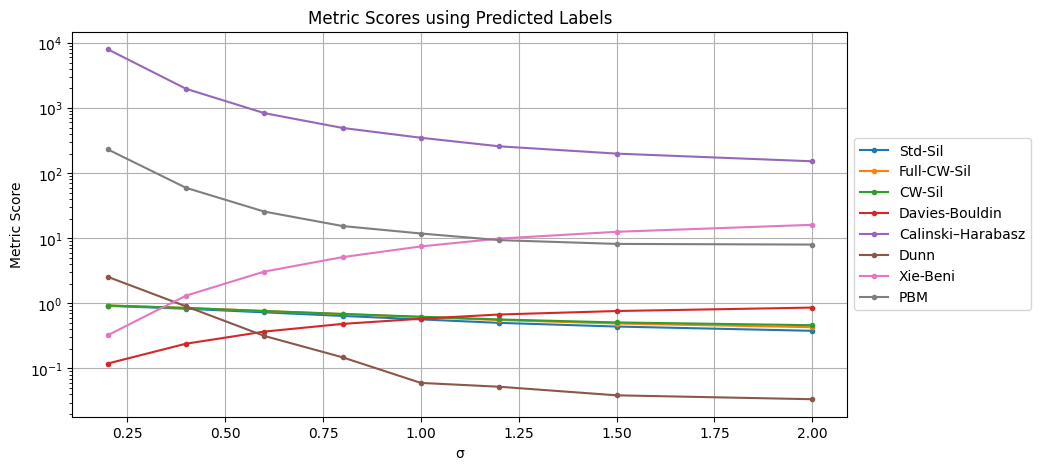

In [13]:
plt.figure(figsize=(10,5))
plt.plot(grouped_k3["std"], grouped_k3["Standard-Silhouette"], label="Std-Sil", marker=".")
plt.plot(grouped_k3["std"], grouped_k3["Full-CW-Silhouette"], label="Full-CW-Sil", marker=".")
plt.plot(grouped_k3["std"], grouped_k3["CW-Silhouette"], label="CW-Sil", marker=".")
plt.plot(grouped_k3["std"], grouped_k3["DBI"], label="Davies-Bouldin", marker=".")
plt.plot(grouped_k3["std"], grouped_k3["CHI"], label="Calinski–Harabasz", marker=".")
plt.plot(grouped_k3["std"], grouped_k3["Dunn"], label="Dunn", marker=".")
plt.plot(grouped_k3["std"], grouped_k3["XBI"], label="Xie-Beni", marker=".")
plt.plot(grouped_k3["std"], grouped_k3["PBM"], label="PBM", marker=".")

plt.axhline(0, linestyle="--")
plt.xlabel("σ")
plt.ylabel("Metric Score")
plt.yscale("log")
plt.title("Metric Scores using Predicted Labels")

# plt.legend()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.grid()

plt.show()

# K-Selection by Each Metric

In [14]:
columns = ["std", "run", "best_std_k", "best_fullcw_k", "best_cw_k", "best_dbi_k", "best_chi_k", "best_dun_k", "best_xbi_k", "best_pbm_k", "best_ari_k", "best_nmi_k"]
df = pd.DataFrame(results, columns=columns)
display(df)

,std,run,best_std_k,best_fullcw_k,best_cw_k,best_dbi_k,best_chi_k,best_dun_k,best_xbi_k,best_pbm_k,best_ari_k,best_nmi_k
0,0.2,0,3,3,3,3,3,3,3,3,3,3
1,0.2,1,3,3,3,3,3,3,3,3,3,3
2,0.2,2,3,3,3,3,3,3,3,3,3,3
3,0.2,3,3,3,3,3,3,3,3,3,3,3
4,0.2,4,3,3,3,3,3,3,3,3,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...
75,2.0,5,3,3,3,6,3,7,8,5,3,3
76,2.0,6,3,3,2,8,3,8,8,4,3,7
77,2.0,7,3,3,3,7,7,6,8,7,3,3
78,2.0,8,3,3,3,8,3,8,6,4,3,4


In [15]:
grouped = df.groupby("std").mean().reset_index()
grouped = grouped.drop("run", axis=1)
display(grouped)

,std,best_std_k,best_fullcw_k,best_cw_k,best_dbi_k,best_chi_k,best_dun_k,best_xbi_k,best_pbm_k,best_ari_k,best_nmi_k
0,0.2,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0
1,0.4,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0
2,0.6,3.0,3.0,3.0,3.0,3.0,2.9,3.0,3.0,3.0,3.0
3,0.8,3.0,3.0,3.0,3.0,3.0,2.8,3.0,3.0,3.0,3.0
4,1.0,3.0,3.0,3.0,3.0,3.0,3.5,4.5,3.0,3.0,3.0
5,1.2,3.0,3.0,3.0,3.0,3.0,4.2,7.8,3.5,3.0,3.0
6,1.5,3.0,3.0,3.0,3.3,3.0,6.9,7.9,4.1,3.0,3.0
7,2.0,3.5,3.5,3.4,7.1,5.3,6.4,7.6,5.1,3.0,4.4


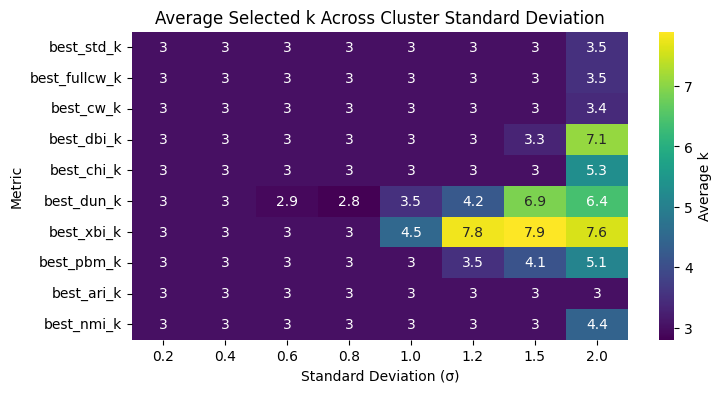

In [16]:
plt.figure(figsize=(8, 4))
sns.heatmap(
    grouped.set_index("std").T,
    annot=True,
    cmap="viridis",
    cbar_kws={"label": "Average k"},
)

plt.xlabel("Standard Deviation (σ)")
plt.ylabel("Metric")
plt.title("Average Selected k Across Cluster Standard Deviation")
plt.show()

# Spearman Correlation of Internal Validation Metrics with External Validation Metrics

In [17]:
columns_corr_ari = ["std", "run", "corr_std", "p_std", "corr_fullcw", "p_fullcw", "corr_cw", "p_cw", "corr_dbi", "p_dbi", "corr_chi", "p_chi", "corr_dun", "p_dun", "corr_xbi", "p_xbi", "corr_pbm", "p_pbm"]
df_corr_ari = pd.DataFrame(results_corr_ari, columns=columns_corr_ari)
display(df_corr_ari)

,std,run,corr_std,p_std,corr_fullcw,p_fullcw,corr_cw,p_cw,corr_dbi,p_dbi,corr_chi,p_chi,corr_dun,p_dun,corr_xbi,p_xbi,corr_pbm,p_pbm
0,0.2,0,0.678571,0.093750,0.714286,0.071344,0.714286,0.071344,0.571429,0.180202,0.892857,0.006807,0.285714,0.534509,-0.250000,0.588724,0.892857,0.006807
1,0.2,1,0.750000,0.052181,0.857143,0.013697,0.857143,0.013697,0.571429,0.180202,0.892857,0.006807,0.571429,0.180202,-0.214286,0.644512,0.892857,0.006807
2,0.2,2,0.821429,0.023449,0.821429,0.023449,0.821429,0.023449,0.571429,0.180202,0.892857,0.006807,0.714286,0.071344,-0.214286,0.644512,0.892857,0.006807
3,0.2,3,0.714286,0.071344,0.821429,0.023449,0.821429,0.023449,0.678571,0.093750,0.892857,0.006807,-0.035714,0.939408,-0.214286,0.644512,0.892857,0.006807
4,0.2,4,0.678571,0.093750,0.678571,0.093750,0.714286,0.071344,0.428571,0.337368,0.892857,0.006807,0.428571,0.337368,-0.214286,0.644512,0.892857,0.006807
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,2.0,5,-0.178571,0.701658,-0.107143,0.819151,0.142857,0.759945,-0.642857,0.119392,-0.142857,0.759945,-0.214286,0.644512,-0.857143,0.013697,-0.428571,0.337368
76,2.0,6,0.357143,0.431611,0.250000,0.588724,0.142857,0.759945,-0.142857,0.759945,0.178571,0.701658,-0.178571,0.701658,-0.714286,0.071344,0.250000,0.588724
77,2.0,7,0.071429,0.879048,0.428571,0.337368,0.642857,0.119392,-0.285714,0.534509,-0.571429,0.180202,0.285714,0.534509,-0.892857,0.006807,-0.857143,0.013697
78,2.0,8,0.214286,0.644512,0.357143,0.431611,0.607143,0.148231,-0.142857,0.759945,0.321429,0.482072,-0.178571,0.701658,-0.357143,0.431611,0.392857,0.383317


In [18]:
grouped_corr_ari = df_corr_ari.groupby("std").mean().reset_index()
grouped_corr_ari = grouped_corr_ari.drop("run", axis=1)
display(grouped_corr_ari)

,std,corr_std,p_std,corr_fullcw,p_fullcw,corr_cw,p_cw,corr_dbi,p_dbi,corr_chi,p_chi,corr_dun,p_dun,corr_xbi,p_xbi,corr_pbm,p_pbm
0,0.2,0.707143,0.078082,0.750000,0.060750,0.757143,0.056268,0.560714,0.197846,0.885714,0.008185,0.421429,0.366101,-0.207143,0.656397,0.892857,0.006807
1,0.4,0.725000,0.070345,0.764286,0.053645,0.800000,0.041442,0.560714,0.202677,0.885714,0.008185,0.341669,0.515605,-0.171429,0.714070,0.892857,0.006807
2,0.6,0.742857,0.064003,0.750000,0.064538,0.785714,0.052865,0.589286,0.192251,0.878571,0.012058,0.325582,0.478351,-0.110714,0.801758,0.842857,0.024700
3,0.8,0.739286,0.063693,0.742857,0.061130,0.785714,0.042745,0.560714,0.196734,0.842857,0.021768,0.481634,0.354800,-0.089286,0.838570,0.875000,0.017130
4,1.0,0.746429,0.060184,0.739286,0.064341,0.750000,0.058884,0.485714,0.277366,0.796429,0.044024,0.103022,0.521038,-0.071429,0.739331,0.860714,0.022311
5,1.2,0.760714,0.077273,0.789286,0.062380,0.778571,0.063166,0.346429,0.466593,0.700000,0.116587,0.078571,0.412971,-0.467857,0.313869,0.725000,0.119308
6,1.5,0.803571,0.069188,0.821429,0.037342,0.835714,0.034718,0.346429,0.494758,0.557143,0.295716,-0.277190,0.487797,-0.632143,0.141475,0.625000,0.192989
7,2.0,0.092857,0.663083,0.085714,0.619442,0.171429,0.453927,-0.353571,0.483257,-0.121429,0.581655,-0.171429,0.517370,-0.728571,0.099176,-0.214286,0.471325


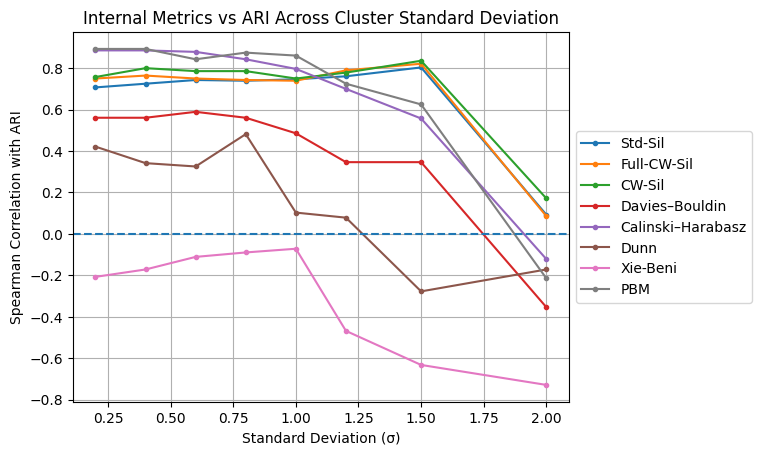

In [19]:
plt.figure()
plt.plot(grouped_corr_ari["std"], grouped_corr_ari["corr_std"], label="Std-Sil", marker=".")
plt.plot(grouped_corr_ari["std"], grouped_corr_ari["corr_fullcw"], label="Full-CW-Sil", marker=".")
plt.plot(grouped_corr_ari["std"], grouped_corr_ari["corr_cw"], label="CW-Sil", marker=".")
plt.plot(grouped_corr_ari["std"], grouped_corr_ari["corr_dbi"], label="Davies–Bouldin", marker=".")
plt.plot(grouped_corr_ari["std"], grouped_corr_ari["corr_chi"], label="Calinski–Harabasz", marker=".")
plt.plot(grouped_corr_ari["std"], grouped_corr_ari["corr_dun"], label="Dunn", marker=".")
plt.plot(grouped_corr_ari["std"], grouped_corr_ari["corr_xbi"], label="Xie-Beni", marker=".")
plt.plot(grouped_corr_ari["std"], grouped_corr_ari["corr_pbm"], label="PBM", marker=".")



plt.axhline(0, linestyle="--")
plt.xlabel("Standard Deviation (σ)")
plt.ylabel("Spearman Correlation with ARI")
plt.title("Internal Metrics vs ARI Across Cluster Standard Deviation")
plt.grid()

# plt.legend()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

In [20]:
columns_corr_nmi = ["std", "run", "corr_std", "p_std", "corr_fullcw", "p_fullcw", "corr_cw", "p_cw", "corr_dbi", "p_dbi", "corr_chi", "p_chi", "corr_dun", "p_dun", "corr_xbi", "p_xbi", "corr_pbm", "p_pbm"]
df_corr_nmi = pd.DataFrame(results_corr_nmi, columns=columns_corr_nmi)
display(df_corr_nmi)

,std,run,corr_std,p_std,corr_fullcw,p_fullcw,corr_cw,p_cw,corr_dbi,p_dbi,corr_chi,p_chi,corr_dun,p_dun,corr_xbi,p_xbi,corr_pbm,p_pbm
0,0.2,0,0.571429,0.180202,0.642857,0.119392,0.642857,0.119392,0.428571,0.337368,0.964286,0.000454,0.178571,0.701658,-0.214286,0.644512,0.964286,0.000454
1,0.2,1,0.607143,0.148231,0.714286,0.071344,0.714286,0.071344,0.428571,0.337368,0.964286,0.000454,0.428571,0.337368,-0.142857,0.759945,0.964286,0.000454
2,0.2,2,0.821429,0.023449,0.821429,0.023449,0.821429,0.023449,0.571429,0.180202,0.892857,0.006807,0.714286,0.071344,-0.214286,0.644512,0.892857,0.006807
3,0.2,3,0.642857,0.119392,0.750000,0.052181,0.750000,0.052181,0.571429,0.180202,0.964286,0.000454,-0.107143,0.819151,-0.142857,0.759945,0.964286,0.000454
4,0.2,4,0.678571,0.093750,0.678571,0.093750,0.714286,0.071344,0.428571,0.337368,0.892857,0.006807,0.428571,0.337368,-0.214286,0.644512,0.892857,0.006807
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,2.0,5,0.464286,0.293934,0.392857,0.383317,0.750000,0.052181,0.035714,0.939408,0.678571,0.093750,-0.428571,0.337368,0.071429,0.879048,0.142857,0.759945
76,2.0,6,-0.750000,0.052181,-0.785714,0.036238,-0.857143,0.013697,-0.178571,0.701658,-0.178571,0.701658,0.071429,0.879048,0.321429,0.482072,-0.107143,0.819151
77,2.0,7,0.607143,0.148231,0.750000,0.052181,0.750000,0.052181,0.714286,0.071344,0.464286,0.293934,0.214286,0.644512,0.071429,0.879048,-0.285714,0.534509
78,2.0,8,0.000000,1.000000,0.071429,0.879048,0.214286,0.644512,0.071429,0.879048,0.357143,0.431611,0.142857,0.759945,-0.178571,0.701658,0.250000,0.588724


In [21]:
grouped_corr_nmi = df_corr_nmi.groupby("std").mean().reset_index()
grouped_corr_nmi = grouped_corr_nmi.drop("run", axis=1)
display(grouped_corr_nmi)

,std,corr_std,p_std,corr_fullcw,p_fullcw,corr_cw,p_cw,corr_dbi,p_dbi,corr_chi,p_chi,corr_dun,p_dun,corr_xbi,p_xbi,corr_pbm,p_pbm
0,0.2,0.657143,0.114587,0.700000,0.085781,0.710714,0.077459,0.496429,0.262287,0.921429,0.005009,0.375000,0.403679,-0.167857,0.708631,0.928571,0.003631
1,0.4,0.685714,0.092498,0.725000,0.075798,0.764286,0.057447,0.528571,0.239411,0.900000,0.006172,0.320241,0.515354,-0.139286,0.755585,0.914286,0.004901
2,0.6,0.692857,0.087367,0.692857,0.088330,0.739286,0.068766,0.528571,0.241610,0.917857,0.004473,0.271816,0.547382,-0.057143,0.843572,0.889286,0.009814
3,0.8,0.621429,0.142631,0.639286,0.129170,0.682143,0.099483,0.428571,0.345878,0.925000,0.005794,0.320629,0.541929,0.071429,0.730435,0.925000,0.007265
4,1.0,0.642857,0.146458,0.628571,0.158285,0.646429,0.144850,0.432143,0.340667,0.821429,0.034382,0.045847,0.519516,0.060714,0.731144,0.810714,0.049284
5,1.2,0.560714,0.238017,0.585714,0.205833,0.628571,0.186357,0.467857,0.343456,0.846429,0.053109,0.067857,0.551143,-0.135714,0.665250,0.650000,0.176332
6,1.5,0.732143,0.099497,0.725000,0.113660,0.671429,0.135050,0.635714,0.178758,0.842857,0.058765,-0.003701,0.563914,-0.117857,0.778764,0.564286,0.243885
7,2.0,0.185714,0.447605,0.071429,0.504409,0.014286,0.479680,0.271429,0.432774,0.428571,0.328109,0.107143,0.590596,0.092857,0.624182,0.050000,0.591394


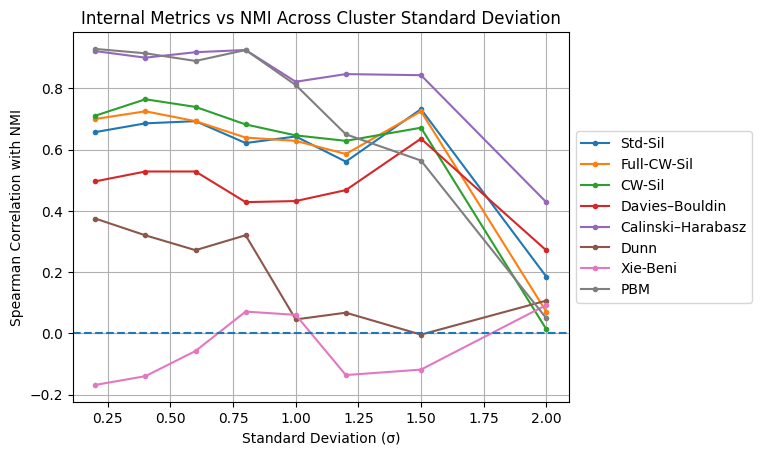

In [22]:
plt.figure()
plt.plot(grouped_corr_nmi["std"], grouped_corr_nmi["corr_std"], label="Std-Sil", marker=".")
plt.plot(grouped_corr_nmi["std"], grouped_corr_nmi["corr_fullcw"], label="Full-CW-Sil", marker=".")
plt.plot(grouped_corr_nmi["std"], grouped_corr_nmi["corr_cw"], label="CW-Sil", marker=".")
plt.plot(grouped_corr_nmi["std"], grouped_corr_nmi["corr_dbi"], label="Davies–Bouldin", marker=".")
plt.plot(grouped_corr_nmi["std"], grouped_corr_nmi["corr_chi"], label="Calinski–Harabasz", marker=".")
plt.plot(grouped_corr_nmi["std"], grouped_corr_nmi["corr_dun"], label="Dunn", marker=".")
plt.plot(grouped_corr_nmi["std"], grouped_corr_nmi["corr_xbi"], label="Xie-Beni", marker=".")
plt.plot(grouped_corr_nmi["std"], grouped_corr_nmi["corr_pbm"], label="PBM", marker=".")



plt.axhline(0, linestyle="--")
plt.xlabel("Standard Deviation (σ)")
plt.ylabel("Spearman Correlation with NMI")
plt.title("Internal Metrics vs NMI Across Cluster Standard Deviation")
plt.grid()

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))


plt.show()

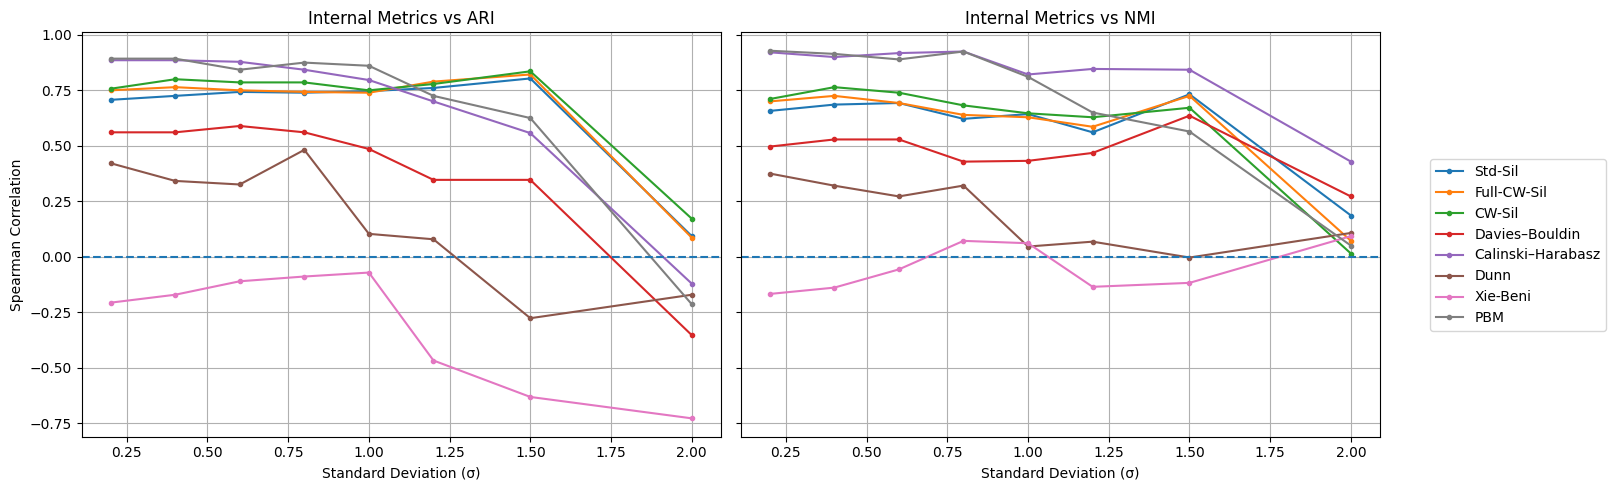

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5), sharey=True)

metrics = [
    ("Std-Sil", "corr_std"),
    ("Full-CW-Sil", "corr_fullcw"),
    ("CW-Sil", "corr_cw"),
    ("Davies–Bouldin", "corr_dbi"),
    ("Calinski–Harabasz", "corr_chi"),
    ("Dunn", "corr_dun"),
    ("Xie-Beni", "corr_xbi"),
    ("PBM", "corr_pbm"),
]

lines = []

# ARI
for label, col in metrics:
    line, = ax1.plot(grouped_corr_ari["std"], grouped_corr_ari[col], marker=".", label=label)
    lines.append(line)

ax1.axhline(0, linestyle="--")
ax1.set_xlabel("Standard Deviation (σ)")
ax1.set_ylabel("Spearman Correlation")
ax1.set_title("Internal Metrics vs ARI")
ax1.grid()


# NMI
for label, col in metrics:
    ax2.plot(grouped_corr_nmi["std"], grouped_corr_nmi[col], marker=".")

ax2.axhline(0, linestyle="--")
ax2.set_xlabel("Standard Deviation (σ)")
ax2.set_title("Internal Metrics vs NMI")
ax2.grid()


fig.legend(lines, [l.get_label() for l in lines], loc="center left", bbox_to_anchor=(1.02, 0.5))

plt.tight_layout()
plt.show()